In [ ]:
!pip install -q sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 76.8 MB/s eta 0:00:00


In [ ]:
import os
import faiss
import numpy as np
import pandas as pd

from tqdm import tqdm
from sentence_transformers import SentenceTransformer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/FIFI_Research/data"

train_df = pd.read_csv(
    os.path.join(DATA_PATH, "train.tsv"),
    sep="\t"
)

val_df = pd.read_csv(
    os.path.join(DATA_PATH, "val.tsv"),
    sep="\t"
)

In [ ]:
candidate_titles = (
    val_df["original_title"]
    .drop_duplicates()
    .tolist()
)

print("Candidate Titles:", len(candidate_titles))

Candidate Titles: 2000


In [ ]:
model = SentenceTransformer(
    "BAAI/bge-base-en-v1.5"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
candidate_embeddings = model.encode(

    candidate_titles,

    batch_size=64,

    show_progress_bar=True,

    normalize_embeddings=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
dimension = candidate_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(candidate_embeddings)

print("FAISS Index Built Successfully!")

FAISS Index Built Successfully!


In [ ]:
query_embeddings = model.encode(

    val_df["generated_title"].tolist(),

    batch_size=64,

    show_progress_bar=True,

    normalize_embeddings=True
)

Batches:   0%|          | 0/282 [00:00<?, ?it/s]

In [ ]:
k = 20

scores, indices = index.search(
    query_embeddings,
    k
)

In [ ]:
retrieved_titles = []

for row in indices:

    retrieved_titles.append(

        [candidate_titles[i] for i in row]

    )

In [ ]:
sample = 0

print("Generated:\n")
print(val_df.iloc[sample]["generated_title"])

print("\nGround Truth:\n")
print(val_df.iloc[sample]["original_title"])

print("\nRetrieved:\n")

for i, title in enumerate(retrieved_titles[sample]):

    print(i+1, title)

Generated:

Fully Convolutional Joint Detection and Regression for Preterm Infant Limb-Pose Estimation from Depth Images

Ground Truth:

Preterm infants' limb-pose estimation from depth images using  convolutional neural networks

Retrieved:

1 Preterm infants' limb-pose estimation from depth images using  convolutional neural networks
2 Back to the Future: Joint Aware Temporal Deep Learning 3D Human Pose  Estimation
3 Real-time Deep Pose Estimation with Geodesic Loss for Image-to-Template  Rigid Registration
4 A Deep Framework for Bone Age Assessment based on Finger Joint  Localization
5 Learning Transferable Kinematic Dictionary for 3D Human Pose and Shape  Reconstruction
6 Peeking into occluded joints: A novel framework for crowd pose  estimation
7 Collaborative Descriptors: Convolutional Maps for Preprocessing
8 Normalization Matters in Weakly Supervised Object Localization
9 Capture Dense: Markerless Motion Capture Meets Dense Pose Estimation
10 Iterative Multi-domain Regularized 

In [ ]:
def reciprocal_rank(predictions, ground_truth):

    for rank, title in enumerate(predictions, start=1):

        if title == ground_truth:

            return 1 / rank

    return 0

In [ ]:
rr_scores = []

for idx in range(len(val_df)):

    rr_scores.append(

        reciprocal_rank(

            retrieved_titles[idx],

            val_df.iloc[idx]["original_title"]

        )

    )

mrr = np.mean(rr_scores)

print(f"MRR@10 : {mrr:.4f}")

MRR@10 : 0.8239


In [ ]:
style_results = []

for style in ["technical", "accessible", "catchy"]:

    subset = val_df[val_df["category"] == style]

    rr = []

    for idx in subset.index:

        rr.append(

            reciprocal_rank(

                retrieved_titles[idx],

                val_df.loc[idx]["original_title"]

            )

        )

    style_results.append({

        "Style": style,

        "MRR@10": np.mean(rr)

    })

style_results = pd.DataFrame(style_results)

style_results

,Style,MRR@10
0,technical,0.950871
1,accessible,0.722357
2,catchy,0.798421


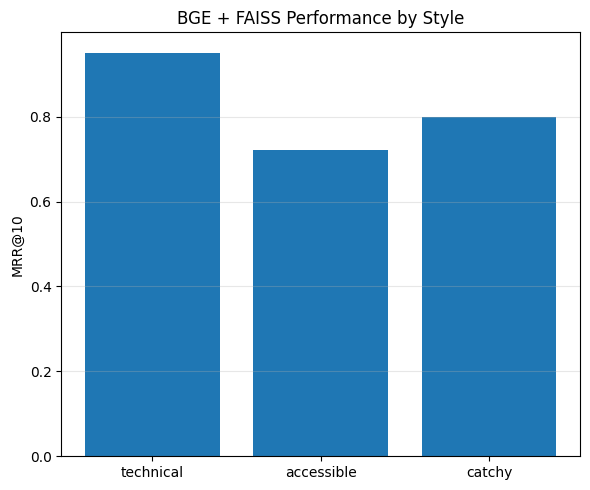

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    style_results["Style"],
    style_results["MRR@10"]
)

plt.ylabel("MRR@10")

plt.title("BGE + FAISS Performance by Style")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
submission = []

for idx, preds in enumerate(retrieved_titles):

    row = {

        "id": val_df.iloc[idx]["id"]

    }

    for i in range(10):

        row[f"rank{i+1}"] = preds[i]

    submission.append(row)

submission_df = pd.DataFrame(submission)

submission_df.to_csv(

    "/content/drive/MyDrive/FIFI_Research/results/BGE_FAISS_validation.tsv",

    sep="\t",

    index=False

)

In [ ]:
errors = []

for idx in range(len(val_df)):

    gt = val_df.iloc[idx]["original_title"]

    preds = retrieved_titles[idx]

    if gt not in preds:

        errors.append({

            "generated_title": val_df.iloc[idx]["generated_title"],

            "ground_truth": gt,

            "top_prediction": preds[0]

        })

errors_df = pd.DataFrame(errors)

errors_df.head(20)

,generated_title,ground_truth,top_prediction
0,A Compact AI System That Predicts What Happens...,"VP-GO: a ""light"" action-conditioned visual pre...",SoftGym: Benchmarking Deep Reinforcement Learn...
1,Training AI Models to Work on New Data by Sepa...,DecAug: Out-of-Distribution Generalization via...,Unadversarial Examples: Designing Objects for ...
2,A More Accurate Way to Discover Network Struct...,An Empirical-Bayes Score for Discrete Bayesian...,A Preference Random Walk Algorithm for Link Pr...
3,Teaching Computers to Automatically Identify a...,DisCont: Self-Supervised Visual Attribute Dise...,Recognizing Objects In-the-wild: Where Do We S...
4,Saving Your Questions for When They Matter: Sm...,Confidence-Budget Matching for Sequential Budg...,Editing-Based SQL Query Generation for Cross-D...
5,Teaching Computers to Understand How People In...,HOTR: End-to-End Human-Object Interaction Dete...,Towards Task Understanding in Visual Settings
6,Improving Digital Image Resolution Using More ...,NeuroTreeNet: A New Method to Explore Horizont...,Hierarchical Neural Architecture Search for Si...
7,A New Reasoning Method for Helping AI Deal wit...,A Novel Fuzzy Approximate Reasoning Method Bas...,Unifying AI Algorithms with Probabilistic Prog...
8,Teaching AI to See Fine Details from Blurry In...,Label Super Resolution with Inter-Instance Loss,Towards Task Understanding in Visual Settings
9,Combining Event-Tracking Models to Improve Pre...,Benefits from Superposed Hawkes Processes,Contrastive Learning for Cold-Start Recommenda...


In [ ]:
errors_df.to_csv(

    "/content/drive/MyDrive/FIFI_Research/results/BGE_FAISS_errors.csv",

    index=False

)

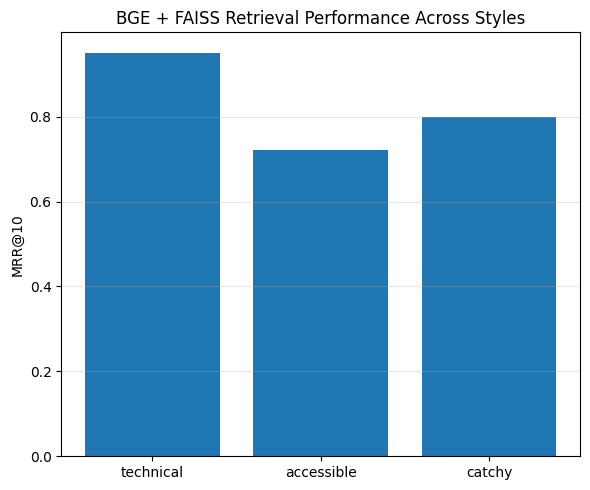

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    style_results["Style"],
    style_results["MRR@10"]
)

plt.ylabel("MRR@10")

plt.title("BGE + FAISS Retrieval Performance Across Styles")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/FIFI_Research/figures/Figure14_BGE_Style_Performance.png",
    dpi=300
)

plt.show()

In [ ]:
submission = []

for idx, preds in enumerate(retrieved_titles):

    row = {"id": val_df.iloc[idx]["id"]}

    ...

In [ ]:
submission_rows = []

for query_idx in range(len(val_df)):

    query_id = val_df.iloc[query_idx]["id"]

    retrieved = retrieved_titles[query_idx]

    retrieved_scores = scores[query_idx]

    for rank in range(10):

        submission_rows.append({

            "id": query_id,

            "rank": rank + 1,

            "score": float(retrieved_scores[rank]),

            "original_title": retrieved[rank]

        })

submission_df = pd.DataFrame(submission_rows)

submission_df.head()

,id,rank,score,original_title
0,0,1,0.935875,Preterm infants' limb-pose estimation from dep...
1,0,2,0.766227,Back to the Future: Joint Aware Temporal Deep ...
2,0,3,0.755445,Real-time Deep Pose Estimation with Geodesic L...
3,0,4,0.742000,A Deep Framework for Bone Age Assessment based...
4,0,5,0.738667,Learning Transferable Kinematic Dictionary for...


In [ ]:
submission_df.to_csv(

"/content/drive/MyDrive/FIFI_Research/submissions/FutureMinds_task1_run1.tsv",

sep="\t",

index=False

)

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/FIFI_Research/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/FIFI_Research/results", exist_ok=True)
os.makedirs("/content/drive/MyDrive/FIFI_Research/submissions", exist_ok=True)

In [ ]:
import pickle

with open(
    "/content/drive/MyDrive/FIFI_Research/models/candidate_titles.pkl",
    "wb"
) as f:
    pickle.dump(candidate_titles, f)

print("Candidate titles saved.")

Candidate titles saved.


In [ ]:
import numpy as np

np.save(
    "/content/drive/MyDrive/FIFI_Research/models/candidate_embeddings.npy",
    candidate_embeddings
)

print("Candidate embeddings saved.")

Candidate embeddings saved.


In [ ]:
np.save(
    "/content/drive/MyDrive/FIFI_Research/models/query_embeddings.npy",
    query_embeddings
)

print("Query embeddings saved.")

Query embeddings saved.


In [ ]:
import faiss

faiss.write_index(
    index,
    "/content/drive/MyDrive/FIFI_Research/models/faiss.index"
)

print("FAISS index saved.")

FAISS index saved.


In [ ]:
np.save(
    "/content/drive/MyDrive/FIFI_Research/models/faiss_indices.npy",
    indices
)

In [ ]:
np.save(
    "/content/drive/MyDrive/FIFI_Research/models/faiss_scores.npy",
    scores
)

In [ ]:
style_results.to_csv(
    "/content/drive/MyDrive/FIFI_Research/results/style_results.csv",
    index=False
)

In [ ]:
errors_df.to_csv(
    "/content/drive/MyDrive/FIFI_Research/results/errors.csv",
    index=False
)

In [ ]:
import os

files = [
    "candidate_titles.pkl",
    "candidate_embeddings.npy",
    "query_embeddings.npy",
    "faiss.index",
    "faiss_indices.npy",
    "faiss_scores.npy"
]

for file in files:
    path = "/content/drive/MyDrive/FIFI_Research/models/" + file
    print(file, ":", os.path.exists(path))

candidate_titles.pkl : True
candidate_embeddings.npy : True
query_embeddings.npy : True
faiss.index : True
faiss_indices.npy : True
faiss_scores.npy : True
